# Notebook 03 — DNB Cover Images

**Project:** Linked Open Exhibition — NFDI4Culture / Hochschule Hannover (BIM-126-02)  
**AI attribution:** GitHub Copilot (Claude Sonnet 4.6)  
**Depends on:** `02_dnb_filter_exhibitions.ipynb` — run that first to produce `sprengel_exhibitions.csv`

**Purpose:** Retrieve cover images from the DNB catalogue enrichment API for each exhibition record that has an ISBN.

---

## Important: image rights disclaimer

> Cover images retrieved via the DNB catalogue enrichment API are **supplied by publishers** and are **not** covered by the CC0 licence that applies to DNB bibliographic metadata.  
> These images are fetched here **for temporary, local, educational use only** (to accompany Wikibase uploads) and **must not be committed to this repository or redistributed**.  
> The `catalogues/images/` directory is listed in `.gitignore`.  
> Always verify image rights before any public reuse.

**DNB cover image URL pattern:**
```
https://portal.dnb.de/opac/mvb/cover?isbn={ISBN}
```

In [3]:
import requests
import pandas as pd
import time
from pathlib import Path

CSV_PATH  = Path("../sprengel_exhibitions.csv")
IMAGE_DIR = Path("../images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

COVER_URL = "https://portal.dnb.de/opac/mvb/cover"

# Read all columns as strings to prevent ISBNs being parsed as floats
df = pd.read_csv(CSV_PATH, dtype=str).fillna("")

with_isbn = df[df["isbn"].str.strip() != ""]
print(f"Records loaded   : {len(df)}")
print(f"Records with ISBN: {len(with_isbn)}")
print(f"\nSample ISBNs:")
print(with_isbn["isbn"].head(5).to_string())

Records loaded   : 582
Records with ISBN: 452

Sample ISBNs:
0    9783775758642
1    9783775758659
2    9783791376226
3    9783864424571
4    9783949924101


## Step 1 — Download cover images

In [4]:
import re

def clean_isbn(raw):
    """Extract digits and X from ISBN string."""
    return re.sub(r"[^0-9X]", "", str(raw).upper())

downloaded = 0
skipped    = 0

for _, row in df.iterrows():
    idn  = str(row["idn"]).strip()
    isbn = clean_isbn(row.get("isbn", ""))

    if not isbn:
        skipped += 1
        continue

    out_path = IMAGE_DIR / f"{idn}.jpg"
    if out_path.exists():
        print(f"  Already exists: {out_path.name}")
        downloaded += 1
        continue

    try:
        resp = requests.get(COVER_URL, params={"isbn": isbn}, timeout=15)
        if resp.status_code == 200 and resp.headers.get("Content-Type", "").startswith("image"):
            out_path.write_bytes(resp.content)
            print(f"  Downloaded: {out_path.name} (ISBN {isbn})")
            downloaded += 1
        else:
            print(f"  No image: IDN {idn} (HTTP {resp.status_code})")
    except requests.RequestException as e:
        print(f"  Error for IDN {idn}: {e}")

    time.sleep(0.5)  # be polite

print(f"\nDownloaded : {downloaded}")
print(f"Skipped (no ISBN): {skipped}")
print(f"Images saved to: {IMAGE_DIR.resolve()}")

  Downloaded: 1375818457.jpg (ISBN 9783775758642)
  Downloaded: 1375817957.jpg (ISBN 9783775758659)
  Downloaded: 1347131019.jpg (ISBN 9783791376226)
  Downloaded: 1357144318.jpg (ISBN 9783864424571)
  No image: IDN 1361486112 (HTTP 404)
  Downloaded: 1375752529.jpg (ISBN 9783891692622)
  Downloaded: 1375750437.jpg (ISBN 9783891692639)
  Downloaded: 1362737259.jpg (ISBN 9783891692615)
  Downloaded: 1366635671.jpg (ISBN 9783891692646)
  Downloaded: 129318635X.jpg (ISBN 9783864424243)
  Downloaded: 1325410217.jpg (ISBN 9783864424373)
  No image: IDN 1376903024 (HTTP 404)
  No image: IDN 1347529314 (HTTP 404)
  Downloaded: 1326056700.jpg (ISBN 9783891692608)
  Downloaded: 1318695635.jpg (ISBN 9783891692585)
  Downloaded: 1315847256.jpg (ISBN 9783960701088)
  Downloaded: 1288765711.jpg (ISBN 9783959057561)
  Downloaded: 1310094683.jpg (ISBN 9783864424311)
  Downloaded: 1277295123.jpg (ISBN 9783868327519)
  Downloaded: 1287958486.jpg (ISBN 9783891692561)
  Downloaded: 1299123732.jpg (ISBN 9

## Step 2 — Preview downloaded images

Display a sample of downloaded covers as a quick visual check.

1000881008.jpg


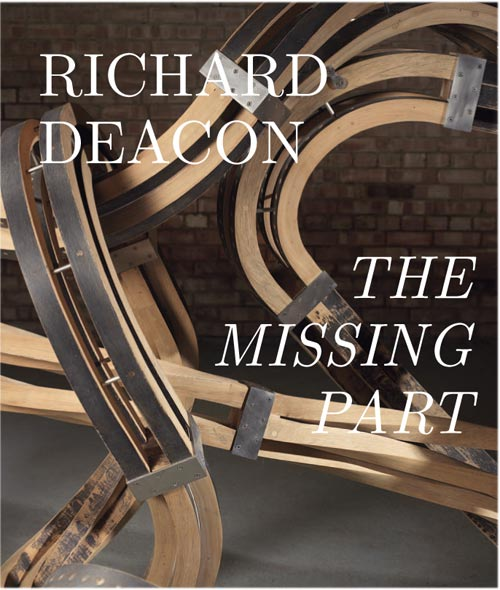

1001547179.jpg


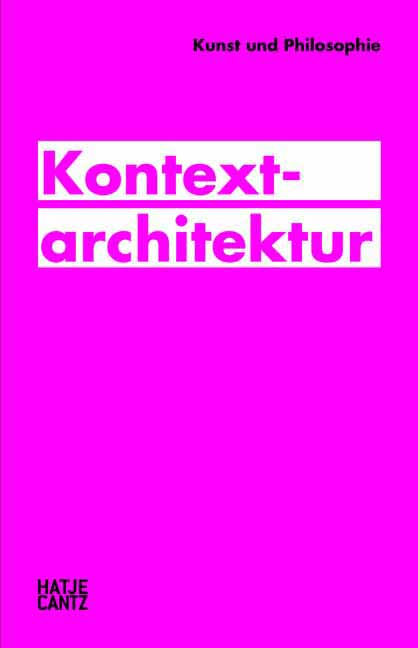

1002017270.jpg


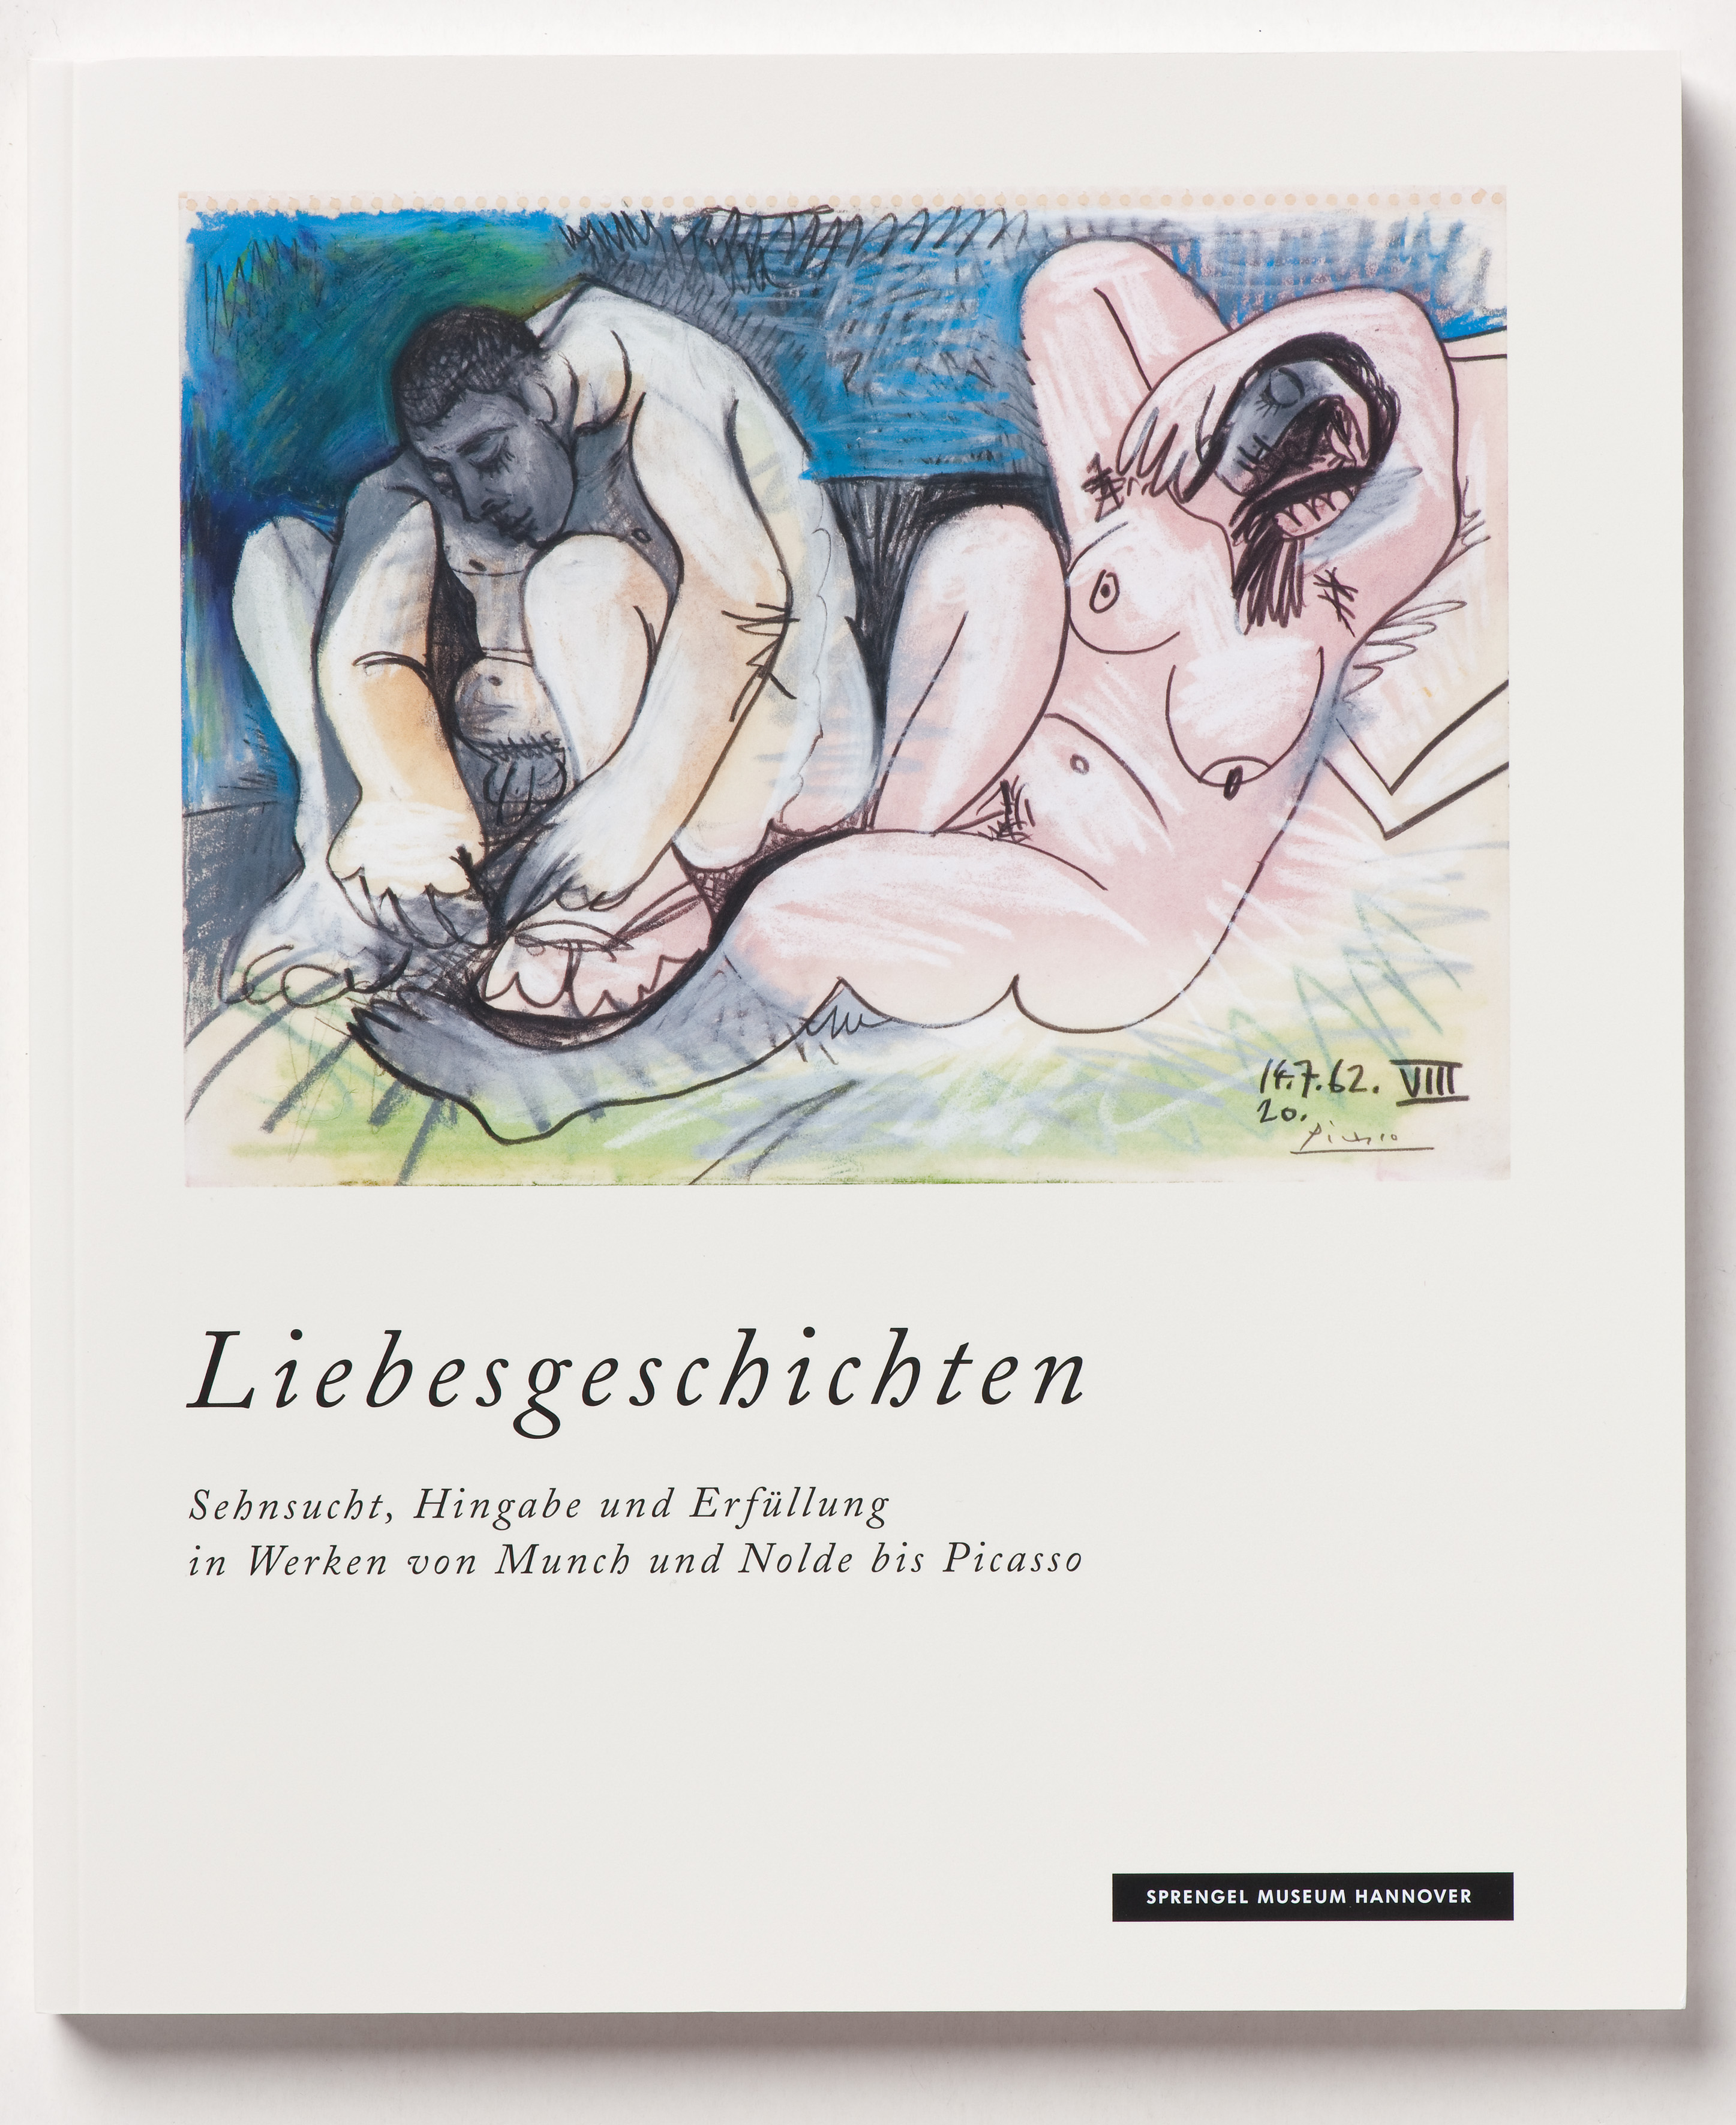

1003246532.jpg


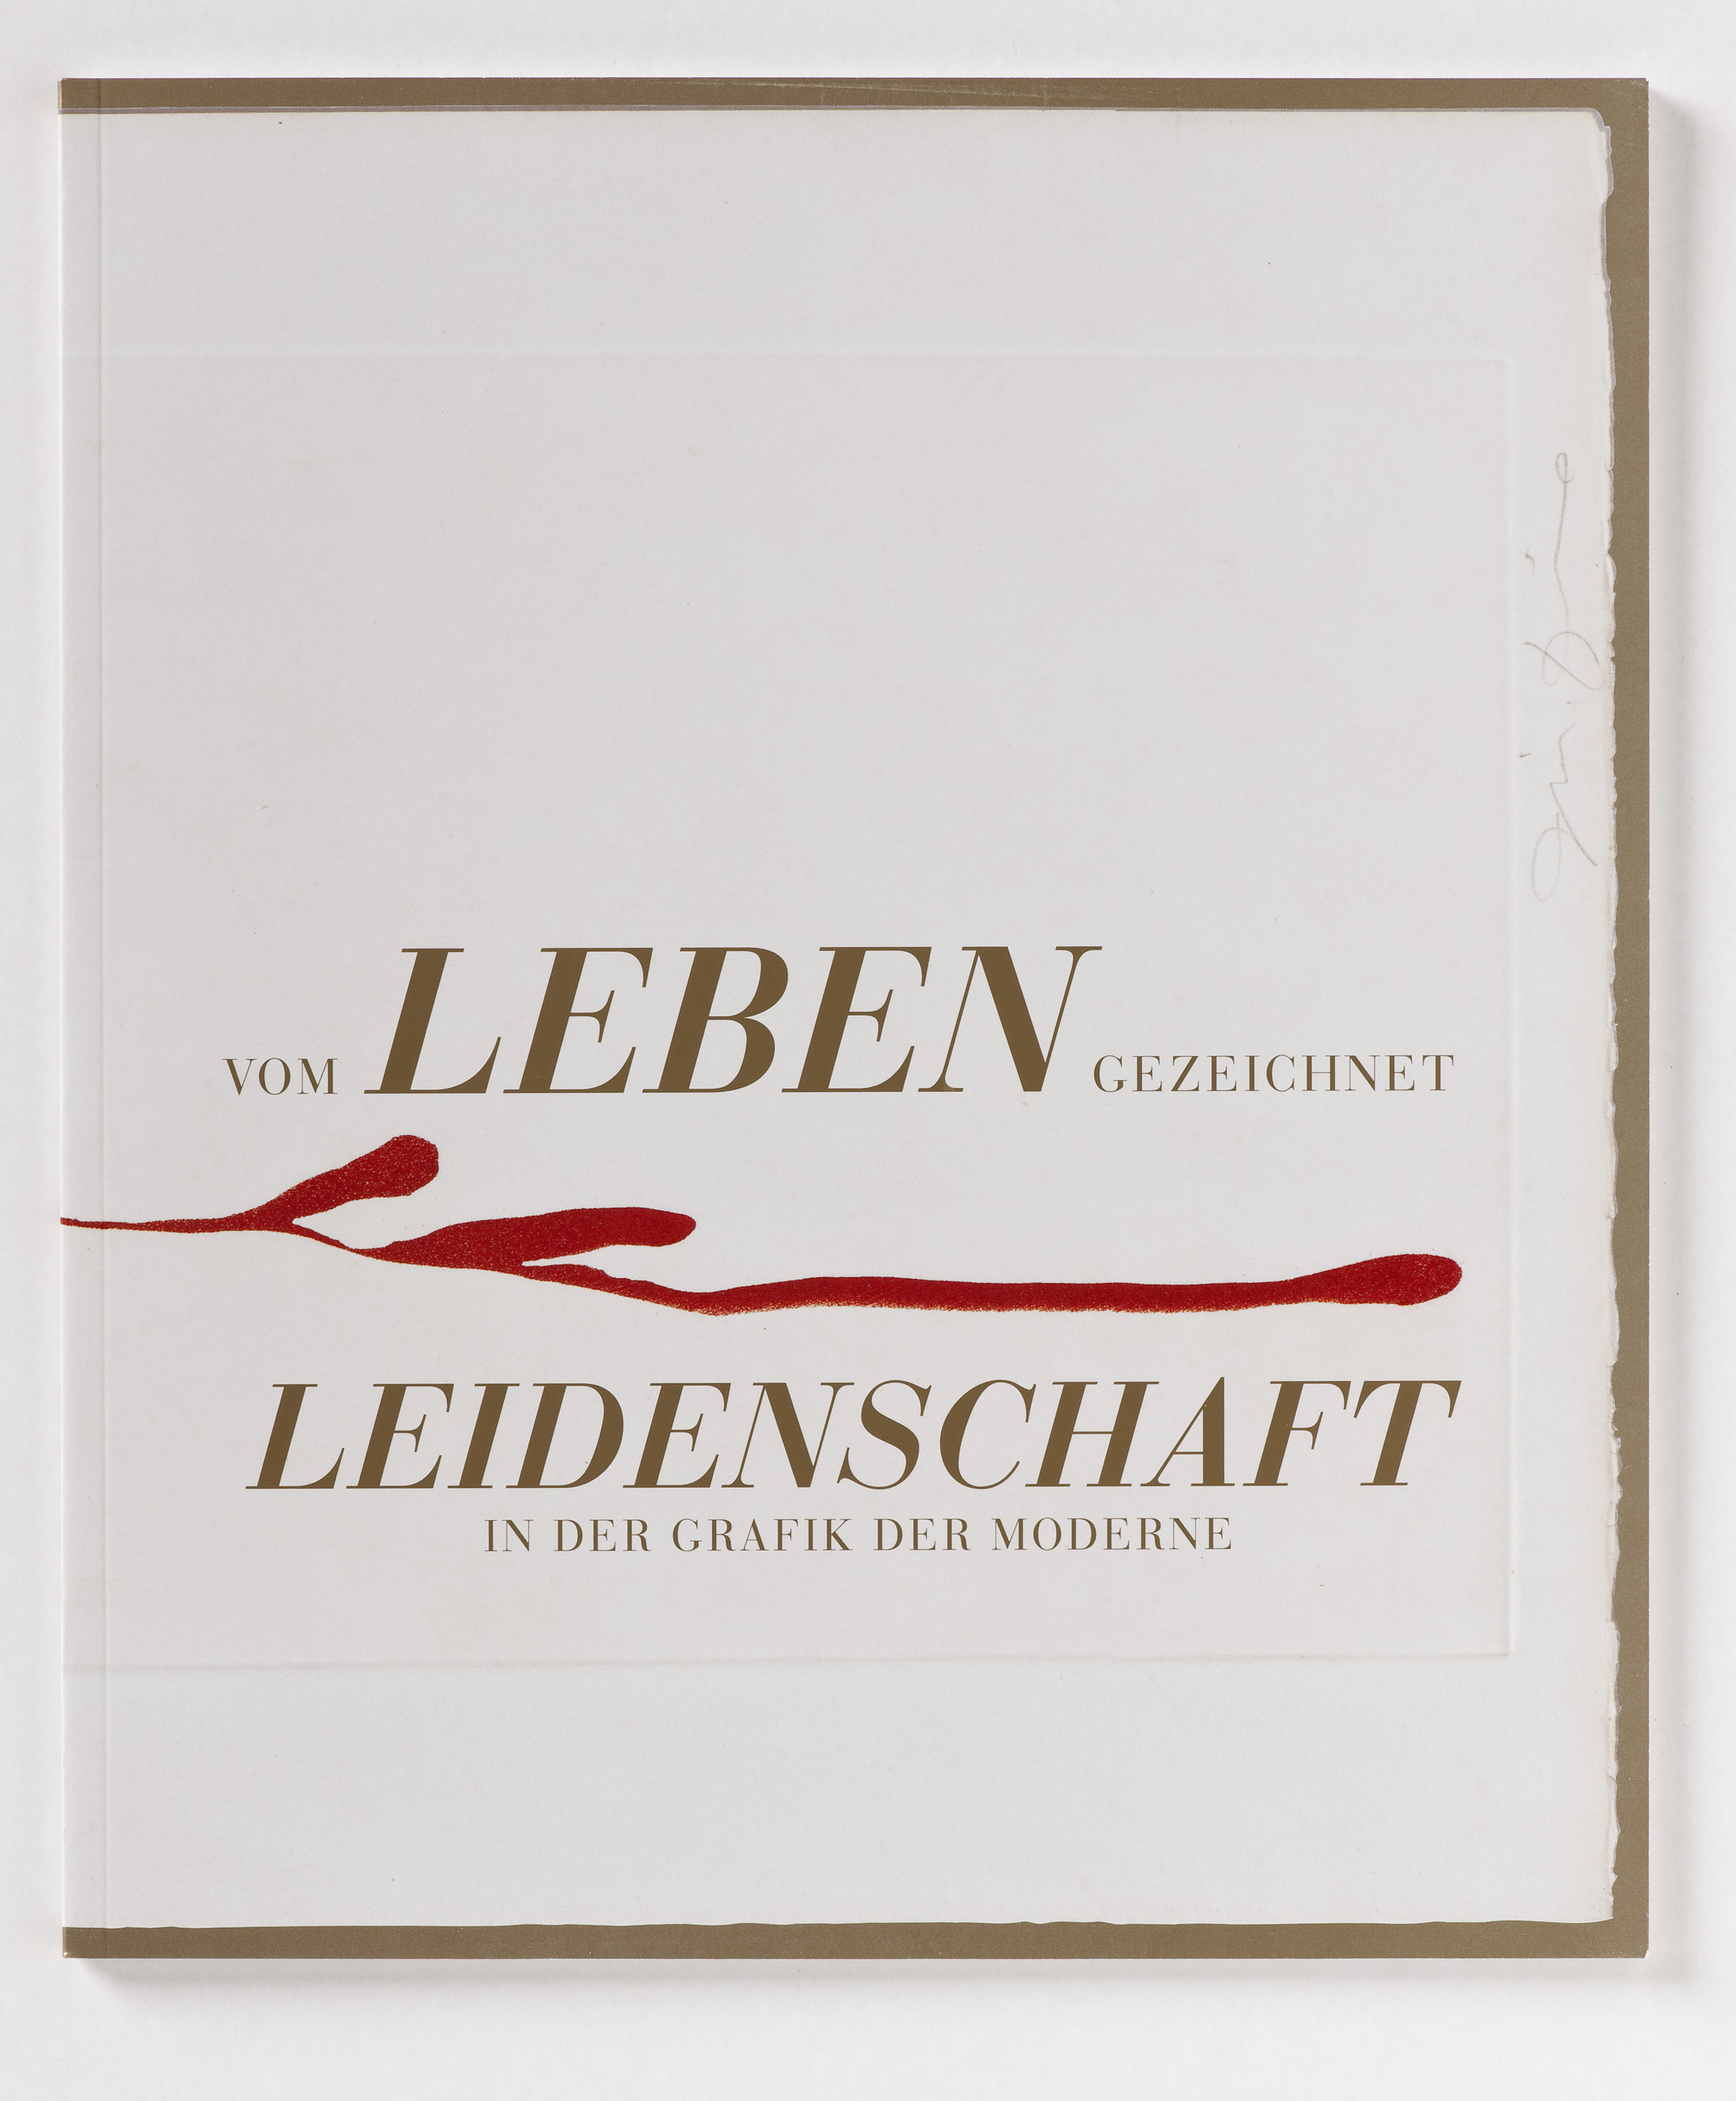

1003832091.jpg


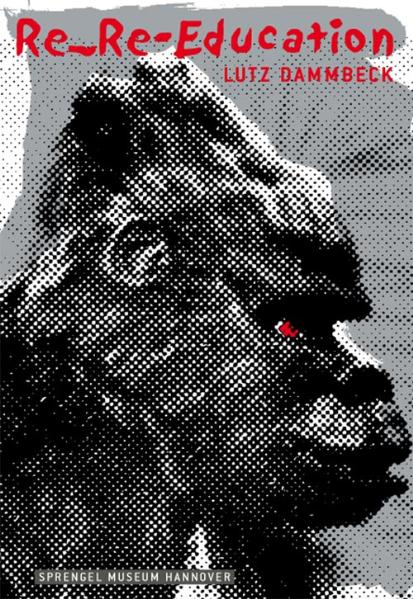

1005908567.jpg


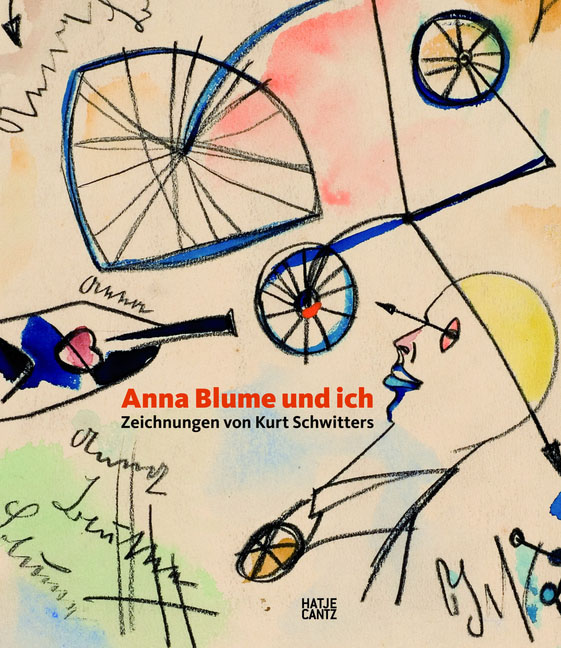

In [5]:
from IPython.display import display, Image as IPImage

image_files = sorted(IMAGE_DIR.glob("*.jpg"))[:6]  # show up to 6

if not image_files:
    print("No images found. Check that ISBNs are present in the CSV.")
else:
    for img_path in image_files:
        print(img_path.name)
        display(IPImage(filename=str(img_path), width=120))

---

**Next step:** Run `04_wikibase_data_model.ipynb` to define and upload the exhibition data model to Wikibase.